# **Testing For Cointegration.**

We are using the Johansen Test to check for Cointegration between 2 or more assets. We must ensure a basket of assets are cointegrated to consistently trade on their mean reversion spreads, orelse their ratios will just exhibit a random walk and deviate further from the mean, where we will never be able to exit out positions.


<h3 style="color: tan;">Import Essential Libraries</h3>

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller


<h3 style="color: tan;">Define Functions</h3>

In [4]:
#Johansen test requires all assets in this list to be non-mean-reverting
def aspread_test(price_series):
    aspread_result = adfuller(price_series)
    p_value = aspread_result[1]
    return p_value < 0.05

#finds optimal lag, required for the k_ar_diff parameter in the Johansen Test
def optimal_lag_selection(time_series):
    model = VAR(time_series)
    lag_order_results = model.select_order(maxlags=10)
    optimal_lag = lag_order_results.aic
    return optimal_lag - 1

def johansen_test(data, start_date, end_date):
    time_series = yf.download(data, start=start_date, end=end_date, auto_adjust=True)["Close"].dropna()

    if aspread_test(time_series[data[0]]) or aspread_test(time_series[data[1]]):
        return "Not applicable for the Johansen Test", -1 , -1

    johansen_result = coint_johansen(
        time_series,
        det_order=0,
        k_ar_diff=optimal_lag_selection(time_series)
    )

    test_stat_trace_r0 = johansen_result.lr1[0]
    critical_value_trace_r0 = johansen_result.cvt[0, 1]
    coint_vector = johansen_result.evec[:, 0]

    return [
        float(test_stat_trace_r0), #Test Statistic of the Test
        float(critical_value_trace_r0), #Critical Value of the Test
    ], time_series, coint_vector

def plot_cointegration(asset_pairs, data, coint_vector):
    spread = data.dot(coint_vector)
    spread.name = "Stationary Spread"
    plt.figure(figsize=(12, 6))
    spread.plot(title=f"Stationary Cointegrating Spread ({asset_pairs[0]} & {asset_pairs[1]})", legend=True)
    mean = spread.mean()
    std = spread.std()
    plt.axhline(mean, color="red", linestyle="--", label="Mean")
    plt.axhline(mean + 2 * std, color="green", linestyle=":", label="+2 Std Dev")
    plt.axhline(mean - 2 * std, color="green", linestyle=":", label="-2 Std Dev")

    plt.legend(loc="upper left")
    plt.ylabel("Spread Value")
    plt.grid(True, alpha=0.5)
    plt.show()

def compute_spread(time_series, coint_vector):
    spread = time_series.dot(coint_vector)
    spread_df = pd.DataFrame(spread, columns=["Spread"])
    return spread_df

def plot_ratio(data, asset):
    ratio = data[asset[0]] / data[asset[1]]
    plt.figure(figsize=(12, 6))
    ratio.plot(title=f"Ratio between ({asset_pairs[0]} & {asset_pairs[1]})", legend=True)
    plt.legend()
    plt.ylabel("Ratio Value")
    plt.grid(True, alpha=0.5)
    plt.show()

<h3 style="color: tan;">Define Parameters and Test for Cointegration</h3>

In [19]:
start_date = "2013-10-01"
end_date = "2023-10-01"
asset_pairs = ["GLD", "SLV"]
result, merged_data, coint_vector = johansen_test(asset_pairs, start_date, end_date)

if result[0] > result[1]:
    print(f'{asset_pairs[0]} and {asset_pairs[1]} are Cointegrated, with Test Statistic of {round(result[0], 2)} and Critical Value of {round(result[1], 2)}')
else:
    print(f'{asset_pairs[0]} and {asset_pairs[1]} are not Cointegrated {result}')

[*********************100%***********************]  2 of 2 completed


GLD and SLV are Cointegrated, with Test Statistic of 15.92 and Critical Value of 15.49


/opt/miniconda3/envs/godepy/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<h3 style="color: tan;">Plot Cointegration</h3>

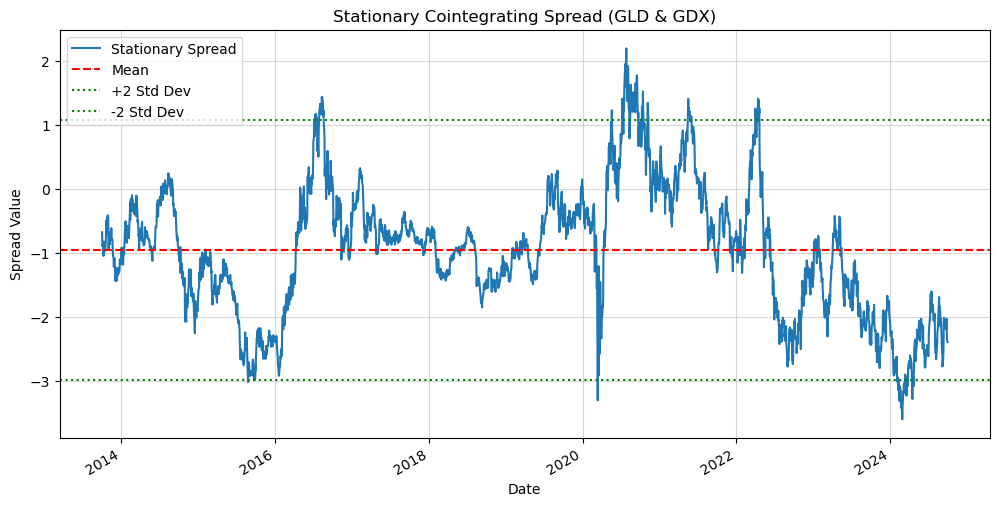

/var/folders/fp/93xv79yn301btyrjs9x_966h0000gn/T/ipykernel_46125/238422835.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


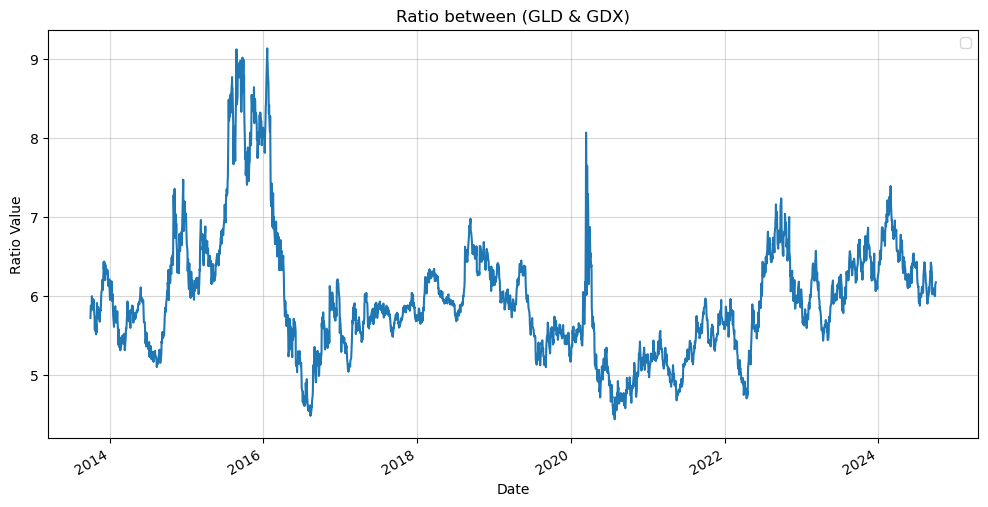

In [18]:
plot_cointegration(asset_pairs, merged_data, coint_vector)
plot_ratio(merged_data, asset_pairs)